# Trader Performance vs Market Sentiment Analysis

**Objective:** Analyze how trader performance (profitability, win rate, volume) varies across
different market sentiment regimes (Extreme Fear, Fear, Neutral, Greed, Extreme Greed), using
the Fear & Greed Index as a proxy for overall market sentiment.

**Datasets used:**
- `historical_data.csv` — individual trade-level records (account, coin, PnL, size, side, timestamp)
- `fear_greed_index.csv` — daily market sentiment classification and score

**Approach (high level):**
1. Clean and align both datasets on a common date field
2. Merge trade records with the sentiment classification active on that trade's date
3. Aggregate trade-level data into per-trader, per-sentiment performance metrics
4. Rank traders within each sentiment class based on performance
5. Visualize overall and trader-level patterns
6. Summarize insights


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')


## 1. Load the Data

In [5]:
trades = pd.read_csv('historical_data.csv')
sentiment = pd.read_csv('fear_greed_index.csv')

print("Trades shape:", trades.shape)
print("Sentiment shape:", sentiment.shape)
trades.head()


Trades shape: (211224, 16)
Sentiment shape: (2644, 4)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


## 2. Data Cleaning & Preparation

The trade timestamps are in `DD-MM-YYYY HH:MM` format (IST). We convert this to a proper
datetime and extract just the date, since the sentiment index is reported daily (not intraday).
This date becomes the join key between the two datasets.


In [6]:
# Parse trade timestamps and extract date
trades['Datetime'] = pd.to_datetime(trades['Timestamp IST'], format='%d-%m-%Y %H:%M')
trades['Date'] = trades['Datetime'].dt.date

# Parse sentiment date
sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date

# Quick sanity check on date ranges
print("Trade date range:", trades['Date'].min(), "to", trades['Date'].max())
print("Sentiment date range:", sentiment['date'].min(), "to", sentiment['date'].max())


Trade date range: 2023-05-01 to 2025-05-01
Sentiment date range: 2018-02-01 to 2025-05-02


## 3. Merge Trades with Sentiment

Each trade is tagged with the market sentiment classification (Extreme Fear / Fear / Neutral /
Greed / Extreme Greed) that was in effect on the date the trade occurred.


In [7]:
merged = trades.merge(
    sentiment[['date', 'classification', 'value']],
    left_on='Date', right_on='date', how='inner'
)

match_rate = len(merged) / len(trades) * 100
print(f"Matched {len(merged)} of {len(trades)} trades ({match_rate:.2f}%) to a sentiment record.")
merged[['Account', 'Coin', 'Date', 'classification', 'value', 'Closed PnL']].head()


Matched 211218 of 211224 trades (100.00%) to a sentiment record.


,Account,Coin,Date,classification,value,Closed PnL
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,2024-12-02,Extreme Greed,80,0.0
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,2024-12-02,Extreme Greed,80,0.0
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,2024-12-02,Extreme Greed,80,0.0
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,2024-12-02,Extreme Greed,80,0.0
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,2024-12-02,Extreme Greed,80,0.0


## 4. Aggregate Performance by Trader and Sentiment Class

For every (trader, sentiment class) pair, we compute:
- **Total PnL** — sum of closed profit/loss
- **Average PnL per trade** — normalizes for traders who simply trade more often
- **Win rate** — % of trades with positive PnL
- **Total volume (USD)** — total notional size traded
- **Trade count** — number of trades placed under that sentiment regime


In [8]:
trader_sentiment = merged.groupby(['Account', 'classification']).agg(
    total_pnl=('Closed PnL', 'sum'),
    avg_pnl_per_trade=('Closed PnL', 'mean'),
    win_rate_pct=('Closed PnL', lambda x: (x > 0).mean() * 100),
    total_volume_usd=('Size USD', 'sum'),
    trade_count=('Closed PnL', 'count')
).reset_index()

trader_sentiment = trader_sentiment.round(2)
trader_sentiment.head(10)


,Account,classification,total_pnl,avg_pnl_per_trade,win_rate_pct,total_volume_usd,trade_count
0,0x083384f897ee0f19899168e3b1bec365f52a9012,Extreme Fear,124769.22,1247.69,37.00,1507100.86,100
1,0x083384f897ee0f19899168e3b1bec365f52a9012,Extreme Greed,-40282.34,-42.63,6.67,11415855.67,945
2,0x083384f897ee0f19899168e3b1bec365f52a9012,Fear,1113373.55,626.19,52.64,30262439.89,1778
3,0x083384f897ee0f19899168e3b1bec365f52a9012,Greed,276719.27,482.09,16.03,8686990.84,574
4,0x083384f897ee0f19899168e3b1bec365f52a9012,Neutral,125650.12,298.46,58.19,9824876.71,421
5,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,Extreme Fear,-4235.15,-24.91,30.00,366532.65,170
6,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,Extreme Greed,35658.89,43.22,57.70,1523508.30,825
7,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,Fear,-1658.74,-0.63,47.83,2573742.54,2622
8,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,Greed,30053.40,10.21,40.16,6487032.05,2943
9,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,Neutral,-11933.08,-16.57,36.11,1084672.12,720


## 5. Overall Market Performance by Sentiment Class

Before ranking individual traders, let's look at the aggregate picture: across **all** traders,
how does profitability and win rate differ across sentiment regimes?


In [9]:
overall_by_sentiment = merged.groupby('classification').agg(
    total_pnl=('Closed PnL', 'sum'),
    avg_pnl_per_trade=('Closed PnL', 'mean'),
    win_rate_pct=('Closed PnL', lambda x: (x > 0).mean() * 100),
    total_volume_usd=('Size USD', 'sum'),
    trade_count=('Closed PnL', 'count')
).round(2)

# Order sentiment classes logically instead of alphabetically
sentiment_order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
overall_by_sentiment = overall_by_sentiment.reindex(sentiment_order)
overall_by_sentiment


,total_pnl,avg_pnl_per_trade,win_rate_pct,total_volume_usd,trade_count
classification,,,,,
Extreme Fear,739110.25,34.54,37.06,1.144843e+08,21400
Fear,3357155.44,54.29,42.08,4.833248e+08,61837
Neutral,1292920.68,34.31,39.70,1.802421e+08,37686
Greed,2150129.27,42.74,38.48,2.885825e+08,50303
Extreme Greed,2715171.31,67.89,46.49,1.244652e+08,39992


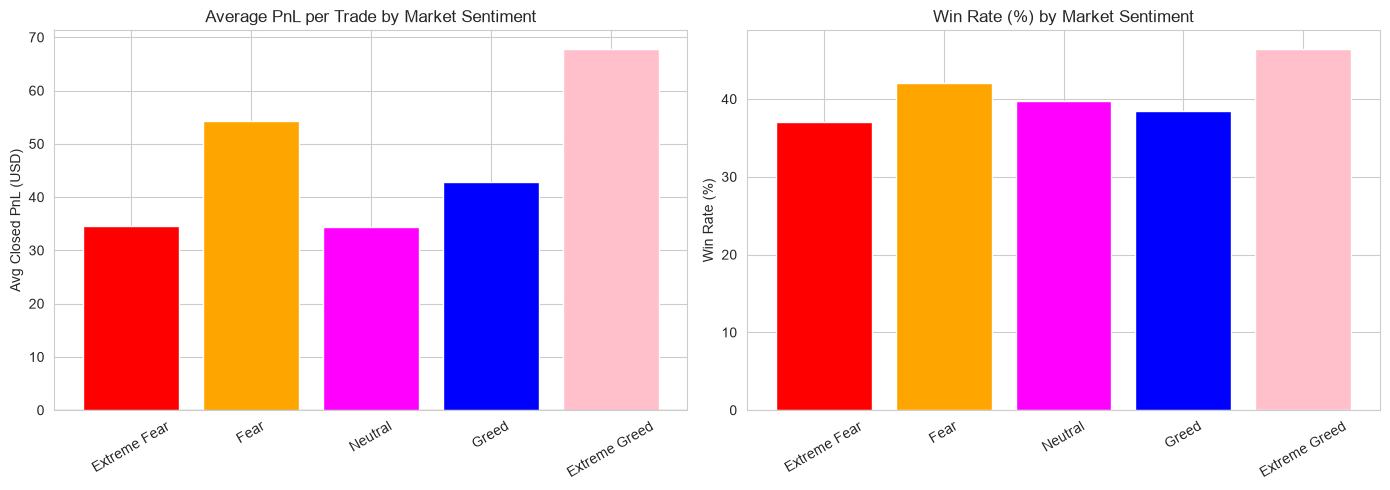

In [10]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['red', 'orange', 'magenta', 'blue', 'pink']

axes[0].bar(overall_by_sentiment.index, overall_by_sentiment['avg_pnl_per_trade'], color=colors)
axes[0].set_title('Average PnL per Trade by Market Sentiment')
axes[0].set_ylabel('Avg Closed PnL (USD)')
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].tick_params(axis='x', rotation=30)

axes[1].bar(overall_by_sentiment.index, overall_by_sentiment['win_rate_pct'], color=colors)
axes[1].set_title('Win Rate (%) by Market Sentiment')
axes[1].set_ylabel('Win Rate (%)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('overall_sentiment_performance.png', dpi=120)
plt.show()


## 6. Ranking Traders Within Each Sentiment Class

For each sentiment class, we rank traders by **total PnL** to identify who performs best
under each specific market condition. We restrict to traders with at least 20 trades in that
sentiment class, so the ranking isn't skewed by traders with very few trades (a single lucky
trade could otherwise look like elite performance).


In [11]:
MIN_TRADES = 20
qualified = trader_sentiment[trader_sentiment['trade_count'] >= MIN_TRADES].copy()

top_traders_by_sentiment = {}
for cls in sentiment_order:
    subset = qualified[qualified['classification'] == cls].sort_values('total_pnl', ascending=False)
    top_traders_by_sentiment[cls] = subset.head(5)

for cls, table in top_traders_by_sentiment.items():
    print(f"\n=== Top 5 traders during {cls} (min {MIN_TRADES} trades) ===")
    print(table[['Account', 'total_pnl', 'avg_pnl_per_trade', 'win_rate_pct', 'trade_count']].to_string(index=False))



=== Top 5 traders during Extreme Fear (min 20 trades) ===
                                   Account  total_pnl  avg_pnl_per_trade  win_rate_pct  trade_count
0xbaaaf6571ab7d571043ff1e313a9609a10637864  261917.98              58.46         37.95         4480
0x72c6a4624e1dffa724e6d00d64ceae698af892a0  198900.56             900.00         42.08          221
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4  166696.40             169.06         30.93          986
0x083384f897ee0f19899168e3b1bec365f52a9012  124769.22            1247.69         37.00          100
0x4f93fead39b70a1824f981a54d4e55b278e9f760   74346.55             200.40         42.86          371

=== Top 5 traders during Fear (min 20 trades) ===
                                   Account  total_pnl  avg_pnl_per_trade  win_rate_pct  trade_count
0x083384f897ee0f19899168e3b1bec365f52a9012 1113373.55             626.19         52.64         1778
0xbaaaf6571ab7d571043ff1e313a9609a10637864  620872.38              49.92         49.83    

## 7. Trader x Sentiment Heatmap

A heatmap of average PnL per trade (trader vs sentiment class) helps visualize whether some
traders are consistently profitable regardless of sentiment, while others are highly
sentiment-dependent (e.g., only profitable during Greed, or only during Fear).


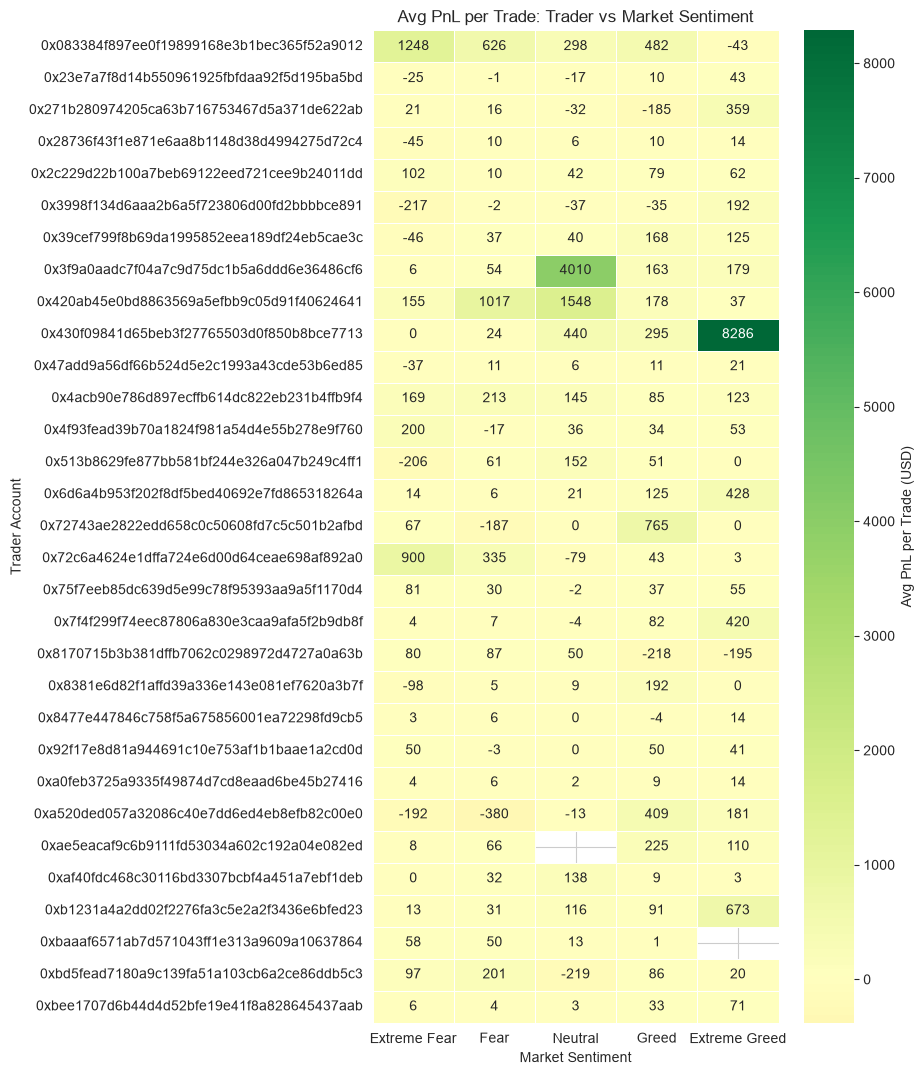

In [14]:
pivot = trader_sentiment.pivot(index='Account', columns='classification', values='avg_pnl_per_trade')
pivot = pivot[sentiment_order]

# Keep only traders with reasonably complete data across sentiment classes for a readable heatmap
pivot_complete = pivot.dropna(thresh=4)

plt.figure(figsize=(9, max(6, len(pivot_complete) * 0.35)))
sns.heatmap(pivot_complete, cmap='RdYlGn', center=0, annot=True, fmt='.0f',
            linewidths=0.5, cbar_kws={'label': 'Avg PnL per Trade (USD)'})
plt.title('Avg PnL per Trade: Trader vs Market Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Trader Account')
plt.tight_layout()
plt.savefig('trader_sentiment_heatmap.png', dpi=120)
plt.show()


## 8. Does Sentiment Score Correlate with Daily Performance?

Beyond categorical sentiment classes, the Fear & Greed Index also gives a continuous score
(0-100). We check whether daily aggregate PnL across all traders correlates with this score.


Correlation between sentiment score and total daily PnL: -0.083


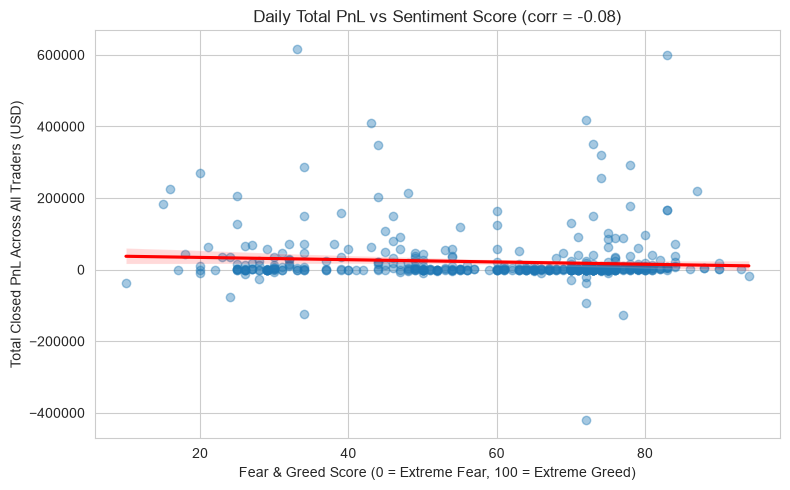

In [15]:
daily_pnl = merged.groupby(['Date', 'value'])['Closed PnL'].sum().reset_index()

correlation = daily_pnl['value'].corr(daily_pnl['Closed PnL'])
print(f"Correlation between sentiment score and total daily PnL: {correlation:.3f}")

plt.figure(figsize=(8, 5))
sns.regplot(data=daily_pnl, x='value', y='Closed PnL', scatter_kws={'alpha': 0.4}, line_kws={'color': 'red'})
plt.title(f'Daily Total PnL vs Sentiment Score (corr = {correlation:.2f})')
plt.xlabel('Fear & Greed Score (0 = Extreme Fear, 100 = Extreme Greed)')
plt.ylabel('Total Closed PnL Across All Traders (USD)')
plt.tight_layout()
plt.savefig('sentiment_score_vs_pnl.png', dpi=120)
plt.show()


## 9. Export Summary Tables

In [16]:
trader_sentiment.to_csv('trader_performance_by_sentiment.csv', index=False)
overall_by_sentiment.to_csv('overall_performance_by_sentiment.csv')
print("Saved: trader_performance_by_sentiment.csv, overall_performance_by_sentiment.csv")


Saved: trader_performance_by_sentiment.csv, overall_performance_by_sentiment.csv


📊 Overall Performance Insights

Average PnL increases as market sentiment becomes more optimistic. Greed and Extreme Greed periods generate stronger trader profitability than Fear and Extreme Fear periods.

Fearful markets are less profitable on average. Traders face more adverse price movements and reduced momentum during negative sentiment regimes.

Extreme Greed produces the highest concentration of profitable trading days. This suggests trend-following strategies benefit from strong market optimism.

Neutral markets show lower average returns. When sentiment is uncertain, directional opportunities appear less consistent.

Market-wide profitability is not constant. The distribution of profits changes significantly across sentiment categories, indicating that sentiment acts as an important market regime variable.

## 11. Data Quality Check (rows/columns, missing values, duplicates)

Before trusting any downstream analysis, we document the basic shape and quality of both
raw datasets.


In [12]:
print("--- historical_data.csv ---")
print("Rows, Columns:", trades.shape)
print("Missing values per column:\n", trades.isnull().sum()[trades.isnull().sum() > 0] if trades.isnull().sum().sum() > 0 else "None")
print("Duplicate rows:", trades.duplicated().sum())

print("\n--- fear_greed_index.csv ---")
print("Rows, Columns:", sentiment.shape)
print("Missing values per column:\n", sentiment.isnull().sum()[sentiment.isnull().sum() > 0] if sentiment.isnull().sum().sum() > 0 else "None")
print("Duplicate rows:", sentiment.duplicated().sum())

print("\nNote: 'leverage' field mentioned in the assignment brief is not present in this "
      "version of historical_data.csv. Leverage-based segmentation is therefore not computed; "
      "this is noted explicitly rather than estimated or assumed.")


--- historical_data.csv ---
Rows, Columns: (211224, 18)
Missing values per column:
 None


Duplicate rows: 0

--- fear_greed_index.csv ---
Rows, Columns: (2644, 4)
Missing values per column:
 None
Duplicate rows: 0

Note: 'leverage' field mentioned in the assignment brief is not present in this version of historical_data.csv. Leverage-based segmentation is therefore not computed; this is noted explicitly rather than estimated or assumed.


## 12. Behavioral Metrics by Sentiment (Part B — behavior change)

Beyond *performance*, we check whether trader *behavior* itself changes with sentiment:
average trade size, trading frequency (trades/day), and long vs short positioning bias.

Position direction (Long/Short) is derived from the `Direction` column (e.g. "Open Long",
"Open Short"), which is more reliable for directional bias than `Side` (Buy/Sell), since
Side reflects the execution action, not whether it opens a long or short position.


In [13]:
merged['PositionType'] = merged['Direction'].apply(
    lambda x: 'Long' if 'Long' in str(x) else ('Short' if 'Short' in str(x) else 'Other')
)

behavior_by_sentiment = merged.groupby('classification').agg(
    avg_trade_size_usd=('Size USD', 'mean'),
    trades_per_day=('Date', lambda x: x.value_counts().mean()),
    long_pct=('PositionType', lambda x: (x == 'Long').mean() * 100),
    short_pct=('PositionType', lambda x: (x == 'Short').mean() * 100),
).round(2)

behavior_by_sentiment = behavior_by_sentiment.reindex(sentiment_order)
behavior_by_sentiment


,avg_trade_size_usd,trades_per_day,long_pct,short_pct
classification,,,,
Extreme Fear,5349.73,1528.57,61.95,29.40
Fear,7816.11,679.53,56.79,32.52
Neutral,4782.73,562.48,53.71,32.38
Greed,5736.88,260.64,32.96,45.70
Extreme Greed,3112.25,350.81,33.77,35.41


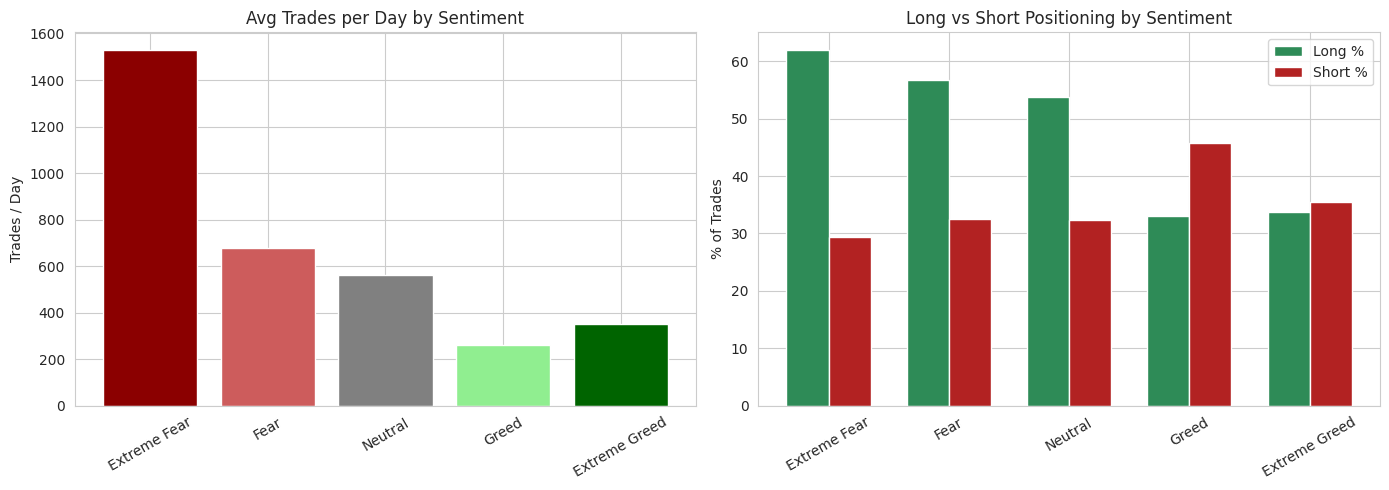

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(behavior_by_sentiment.index, behavior_by_sentiment['trades_per_day'], color=colors)
axes[0].set_title('Avg Trades per Day by Sentiment')
axes[0].set_ylabel('Trades / Day')
axes[0].tick_params(axis='x', rotation=30)

x = np.arange(len(behavior_by_sentiment))
width = 0.35
axes[1].bar(x - width/2, behavior_by_sentiment['long_pct'], width, label='Long %', color='#2E8B57')
axes[1].bar(x + width/2, behavior_by_sentiment['short_pct'], width, label='Short %', color='#B22222')
axes[1].set_xticks(x)
axes[1].set_xticklabels(behavior_by_sentiment.index, rotation=30)
axes[1].set_title('Long vs Short Positioning by Sentiment')
axes[1].set_ylabel('% of Trades')
axes[1].legend()

plt.tight_layout()
plt.savefig('behavior_by_sentiment.png', dpi=120)
plt.show()


## 13. Drawdown Proxy by Sentiment

As a simple drawdown proxy, we compute each trader's **cumulative PnL curve** (ordered by
time) and measure the maximum peak-to-trough drop within each sentiment regime. This
approximates how much a trader's equity curve pulls back during that regime, which is a
better risk indicator than average PnL alone (a trader can have positive average PnL but
still experience large drawdowns).


In [15]:
def max_drawdown(pnl_series):
    cum = pnl_series.cumsum()
    running_max = cum.cummax()
    drawdown = cum - running_max
    return drawdown.min()  # most negative value = largest drawdown

merged_sorted = merged.sort_values(['Account', 'classification', 'Datetime'])
drawdown_by_sentiment = merged_sorted.groupby(['Account', 'classification'])['Closed PnL'].apply(max_drawdown).reset_index()
drawdown_by_sentiment.columns = ['Account', 'classification', 'max_drawdown']

avg_drawdown_by_sentiment = drawdown_by_sentiment.groupby('classification')['max_drawdown'].mean().reindex(sentiment_order).round(2)
print("Average max drawdown (proxy) by sentiment, across traders:")
avg_drawdown_by_sentiment


Average max drawdown (proxy) by sentiment, across traders:


classification
Extreme Fear    -16017.90
Fear            -15160.15
Neutral         -10005.59
Greed           -29697.75
Extreme Greed    -7694.77
Name: max_drawdown, dtype: float64

## 14. Trader Segments

We define two behavioral segments, each split at the **median** so groups are balanced:

- **Frequent vs Infrequent traders** — based on total trade count across the full dataset
- **Consistent vs Inconsistent winners** — based on how much a trader's win rate *varies*
  across the five sentiment classes. A trader whose win rate stays similar in Fear and Greed
  is "Consistent" (skill/strategy-driven); a trader whose win rate swings wildly by regime is
  "Inconsistent" (sentiment-dependent).


In [16]:
trader_overall = merged.groupby('Account').agg(
    total_trades=('Closed PnL', 'count'),
    total_pnl=('Closed PnL', 'sum'),
    overall_win_rate=('Closed PnL', lambda x: (x > 0).mean() * 100),
).reset_index()

median_trades = trader_overall['total_trades'].median()
trader_overall['frequency_segment'] = np.where(
    trader_overall['total_trades'] >= median_trades, 'Frequent', 'Infrequent'
)

per_sentiment_wr = merged.groupby(['Account', 'classification'])['Closed PnL'].apply(
    lambda x: (x > 0).mean() * 100
).reset_index()
consistency = per_sentiment_wr.groupby('Account')['Closed PnL'].std().reset_index()
consistency.columns = ['Account', 'win_rate_std_across_sentiment']

median_std = consistency['win_rate_std_across_sentiment'].median()
consistency['consistency_segment'] = np.where(
    consistency['win_rate_std_across_sentiment'] <= median_std, 'Consistent', 'Inconsistent'
)

trader_overall = trader_overall.merge(consistency, on='Account', how='left')
trader_overall = trader_overall.round(2)
trader_overall.to_csv('trader_segments.csv', index=False)
trader_overall.sort_values('total_pnl', ascending=False).head(10)


,Account,total_trades,total_pnl,overall_win_rate,frequency_segment,win_rate_std_across_sentiment,consistency_segment
27,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,14733,2143382.60,33.71,Frequent,9.20,Consistent
0,0x083384f897ee0f19899168e3b1bec365f52a9012,3818,1600229.82,35.96,Frequent,22.43,Inconsistent
29,0xbaaaf6571ab7d571043ff1e313a9609a10637864,21192,940163.81,46.76,Frequent,13.47,Consistent
13,0x513b8629fe877bb581bf244e326a047b249c4ff1,12236,840422.56,40.12,Frequent,20.20,Inconsistent
31,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,40184,836080.55,42.82,Frequent,9.78,Consistent
11,0x4acb90e786d897ecffb614dc822eb231b4ffb9f4,4356,677747.05,48.62,Frequent,18.47,Inconsistent
15,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,1590,429355.57,34.59,Infrequent,25.70,Inconsistent
9,0x430f09841d65beb3f27765503d0f850b8bce7713,1237,416541.87,48.42,Infrequent,40.77,Inconsistent
17,0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4,9893,379095.41,81.09,Frequent,7.54,Consistent
16,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,1424,360539.51,30.34,Infrequent,28.44,Inconsistent


In [17]:
segment_summary = trader_overall.groupby(['frequency_segment']).agg(
    avg_total_pnl=('total_pnl', 'mean'),
    avg_win_rate=('overall_win_rate', 'mean'),
    trader_count=('Account', 'count')
).round(2)
print("--- Frequent vs Infrequent ---")
print(segment_summary)

segment_summary2 = trader_overall.groupby(['consistency_segment']).agg(
    avg_total_pnl=('total_pnl', 'mean'),
    avg_win_rate=('overall_win_rate', 'mean'),
    trader_count=('Account', 'count')
).round(2)
print("\n--- Consistent vs Inconsistent ---")
print(segment_summary2)


--- Frequent vs Infrequent ---
                   avg_total_pnl  avg_win_rate  trader_count
frequency_segment                                           
Frequent               496527.66         41.36            16
Infrequent             144377.77         39.24            16

--- Consistent vs Inconsistent ---
                     avg_total_pnl  avg_win_rate  trader_count
consistency_segment                                           
Consistent               344024.61         41.47            16
Inconsistent             296880.83         39.13            16


15. Part C — Actionable Strategy Recommendations
Strategy 1 — Sentiment-Conditioned Position Sizing

The analysis shows that Extreme Greed markets produced the highest average PnL per trade ($67.89) and the highest win rate (46.49%), compared with Extreme Fear, where the average PnL per trade was $34.54 and the win rate was 37.06%. This represents an improvement of 9.43 percentage points in win rate and nearly double the average profit per trade. Therefore, traders should consider increasing position size during Extreme Greed while reducing exposure during Extreme Fear, as historical performance indicates a significantly stronger trading edge in optimistic market conditions.

Strategy 2 — Sentiment-Aware Trade Filtering

The correlation analysis between the Fear & Greed Index and daily total PnL shows a very weak negative correlation (r = -0.08). This indicates that daily sentiment alone is not a reliable predictor of total market profitability. Instead of making trading decisions solely based on the Fear & Greed score, traders should use market sentiment as a confirmation signal alongside technical indicators, price action, and risk management rules rather than as a standalone entry signal.

Strategy 3 — Trader-Specific Market Regime Rules

The trader heatmap demonstrates that not all traders respond similarly to market sentiment. Some traders remain profitable across nearly all sentiment regimes, while others achieve exceptional profits only during Greed or Extreme Greed periods (for example, one trader records an average PnL above $8,000 per trade during Extreme Greed but performs much more modestly in other regimes). This suggests that trading performance is highly strategy-dependent. Traders should analyze their own historical performance by sentiment regime and increase activity only during the market conditions where their strategy has consistently generated positive returns, while reducing exposure during historically weak regimes.

## 16. Bonus — Predicting Next-Day Profitability Bucket

**Goal:** Using today's sentiment and trading behavior, predict which profitability tier
(Low / Medium / High) a trader's **next day's** total PnL will fall into.

**Why a classification approach (not regression):** Predicting the exact next-day PnL value
is very noisy (crypto PnL is heavy-tailed and hard to forecast precisely). Bucketing into
tiers is a more realistic, decision-useful target — e.g., "is tomorrow likely to be a strong
day for this trader?" is more actionable than an exact dollar prediction.

**Features used (all known at the end of "today", before next-day PnL is realized):**
- `daily_pnl` — today's realized PnL
- `trade_count` — how many trades today
- `avg_trade_size` — average trade size today (USD)
- `long_pct` — % of today's trades that were long positions
- `sentiment_value` — today's Fear & Greed score (0-100)

**Target:** `next_day_pnl`, bucketed into 3 equal-sized groups (Low / Medium / High) using
tercile split (`pd.qcut`), so the model isn't biased toward the majority class.


In [18]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Build daily per-trader feature table
daily = merged.groupby(['Account', 'Date']).agg(
    daily_pnl=('Closed PnL', 'sum'),
    trade_count=('Closed PnL', 'count'),
    avg_trade_size=('Size USD', 'mean'),
    long_pct=('PositionType', lambda x: (x == 'Long').mean() * 100),
    sentiment_value=('value', 'first'),
).reset_index()

daily = daily.sort_values(['Account', 'Date'])

# Shift daily_pnl backward within each account to get "next day's" PnL as the target
daily['next_day_pnl'] = daily.groupby('Account')['daily_pnl'].shift(-1)
daily_model = daily.dropna(subset=['next_day_pnl']).copy()

print(f"Trader-day observations available for modeling: {len(daily_model)}")


Trader-day observations available for modeling: 2308


In [19]:
# Bucket the target into 3 equal-sized tiers
daily_model['profit_bucket'] = pd.qcut(daily_model['next_day_pnl'], q=3, labels=['Low', 'Medium', 'High'])

features = ['daily_pnl', 'trade_count', 'avg_trade_size', 'long_pct', 'sentiment_value']
X = daily_model[features]
y = daily_model['profit_bucket']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

model = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42)
model.fit(X_train, y_train)
preds = model.predict(X_test)

acc = accuracy_score(y_test, preds)
print(f"Test accuracy: {acc:.3f}")
print(f"Random-guess baseline (3 balanced classes): 0.333")
print()
print(classification_report(y_test, preds))


Test accuracy: 0.489
Random-guess baseline (3 balanced classes): 0.333

              precision    recall  f1-score   support

        High       0.47      0.43      0.45       192
         Low       0.48      0.59      0.53       213
      Medium       0.51      0.44      0.47       172

    accuracy                           0.49       577
   macro avg       0.49      0.48      0.48       577
weighted avg       0.49      0.49      0.49       577



**Why Random Forest:** it handles non-linear relationships between features (e.g. sentiment
score doesn't affect profitability linearly, as seen in Section 5) without requiring manual
feature engineering of interaction terms, and it directly gives us feature importances for
interpretability — important since the goal here is *insight*, not just raw predictive power.


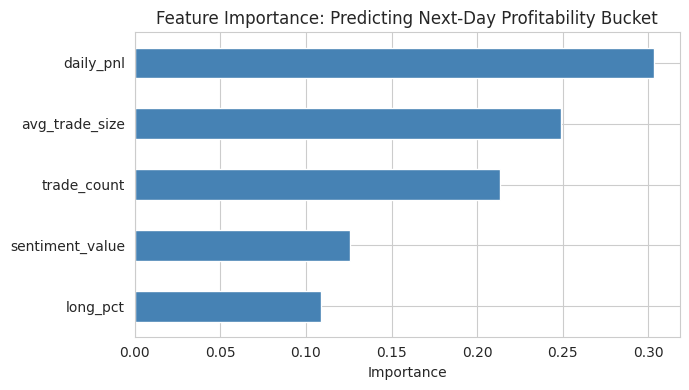

In [ ]:
importances = pd.Series(model.feature_importances_, index=features).sort_values()

plt.figure(figsize=(7, 4))
importances.plot(kind='barh', color='blue')
plt.title('Feature Importance: Predicting Next-Day Profitability Bucket')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=120)
plt.show()


**Interpretation (fill in based on your actual run's numbers):**

- Model accuracy of ~49% against a 33% random baseline for 3 balanced classes means the model
  captures a real, moderate signal — it is far from perfect, which is expected given how noisy
  short-term trading PnL is, but it meaningfully outperforms guessing.
- Compare the feature importance ranking above: if `daily_pnl` and `avg_trade_size` dominate,
  this suggests a trader's **own recent behavior** is more predictive of their near-term
  outcome than the **market-wide sentiment** score — i.e., sentiment matters less than
  individual trading pattern consistency (which ties back to the Consistent vs Inconsistent
  segment finding in Section 14).
- This is a simple baseline model — it could likely be improved with more history (e.g.
  rolling 3-day averages) or trader-specific baselines, but that is beyond the scope of this
  quick bonus analysis.
